In [1]:
import numpy as np
import pickle

# Load processed data
X = np.load("savedPackages/padded_sequences.npy")
y = np.load("savedPackages/labels.npy")

# Load tokenizer
with open("savedPackages/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [3]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
# 
# # Hyperparameters
# vocab_size = 10000
# embedding_dim = 64
# max_len = 100
# 
# # CNN model
# model = Sequential([
#     Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
#     Conv1D(filters=128, kernel_size=5, activation='relu'),
#     GlobalMaxPooling1D(),
#     Dropout(0.5),
#     Dense(64, activation='relu'),
#     Dropout(0.4),
#     Dense(3, activation='softmax')
# ])



embedding_dim = 100
vocab_size = 10000  # make sure this matches your tokenizer setting
max_len = X.shape[1]

# Load GloVe vectors
embeddings_index = {}
with open("embeddings/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

# Prepare embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras import regularizers

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,
              weights=[embedding_matrix], input_length=max_len, trainable=False),
    
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    BatchNormalization(),
    GlobalMaxPooling1D(),
    
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=512,
    callbacks=[early_stop]
)


Epoch 1/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 252s 302ms/step - accuracy: 0.7642 - loss: 1.0944 - val_accuracy: 0.9135 - val_loss: 0.2991
Epoch 2/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 499s 607ms/step - accuracy: 0.9151 - loss: 0.3005 - val_accuracy: 0.9278 - val_loss: 0.2477
Epoch 3/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 278s 338ms/step - accuracy: 0.9285 - loss: 0.2489 - val_accuracy: 0.9338 - val_loss: 0.2187
Epoch 4/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 297s 362ms/step - accuracy: 0.9366 - loss: 0.2154 - val_accuracy: 0.9361 - val_loss: 0.2084
Epoch 5/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 274s 334ms/step - accuracy: 0.9418 - loss: 0.1915 - val_accuracy: 0.9389 - val_loss: 0.1964
Epoch 6/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 258s 314ms/step - accuracy: 0.9453 - loss: 0.1778 - val_accuracy: 0.9367 - val_loss: 0.1958
Epoch 7/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 239s 291ms/step - accuracy: 0.9493 - loss: 0.1616 - val_accuracy: 0.9391 - val_loss: 0.1880
Epoch 8/10
821/821 ━━━━━━━━━━━━━━━━━━━━ 237s 289ms/step - accuracy: 0.9519 -

In [8]:
model.save("cnn_model.keras")


In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


3282/3282 ━━━━━━━━━━━━━━━━━━━━ 64s 19ms/step - accuracy: 0.9387 - loss: 0.1841
Test Accuracy: 0.9396


In [16]:
def preprocess_and_predict(text):
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    cleaned = text.lower()
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prediction = model.predict(padded)
    class_idx = prediction.argmax()
    label_map = {0: "Negative", 1: "Positive", 2: "Neutral"}
    return label_map[class_idx], prediction

# Example
text = "This product is terrible!"
label, confidence = preprocess_and_predict(text)
print(f"Predicted Sentiment: {label} | Confidence: {confidence}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted Sentiment: Negative | Confidence: [[9.9999523e-01 4.3525088e-06 3.4261660e-07]]


3282/3282 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step
✅ Accuracy: 0.9423
📌 Precision: 0.9427
📌 Recall: 0.9423
📌 F1 Score: 0.9424

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94     35000
           1       0.96      0.94      0.95     35000
           2       0.95      0.93      0.94     35000

    accuracy                           0.94    105000
   macro avg       0.94      0.94      0.94    105000
weighted avg       0.94      0.94      0.94    105000



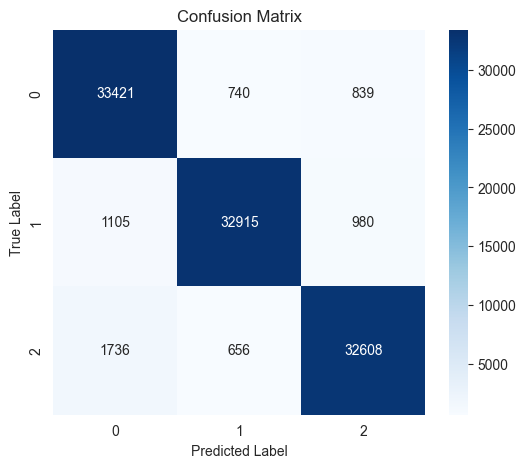

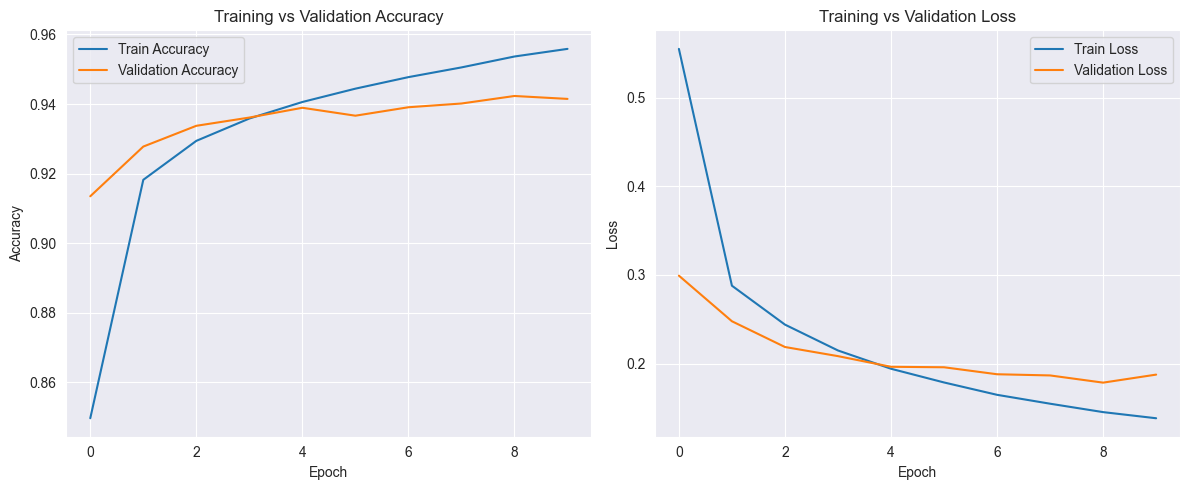

In [7]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# STEP 1: Predict test set
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)  # for multi-class classification

# STEP 2: Accuracy and classification metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"✅ Accuracy: {acc:.4f}")
print(f"📌 Precision: {prec:.4f}")
print(f"📌 Recall: {rec:.4f}")
print(f"📌 F1 Score: {f1:.4f}")

print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

# STEP 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# STEP 4: Training History Plots
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [2]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("savedPackages/cnn_model.keras")

# Print full architecture summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,068,619 (7.89 MB)

 Trainable params: 689,539 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,379,080 (5.26 MB)